# Step 4 & 5 — Data Science Analysis & Maintenance Recommendations
## SplitSmart Dataset | Goa A200 AC Units (AC01, AC02, AC03)

**Dataset:** 503,678 records · 3 ductless-split AC units · Mar 2020 – Aug 2021  
**Tools:** Python · pandas · scikit-learn · matplotlib · seaborn

---

### Notebook Structure

| Section | Topic |
|---------|-------|
| 4.1 | Feature Engineering |
| 4.2 | Anomaly Detection — Isolation Forest |
| 4.3 | PF Monitoring Alert — Rule-Based Rolling Window |
| 4.4 | Real Power Regression — Linear vs Random Forest |
| 5.1 | Unit-Level Maintenance Recommendations |
| 5.2 | Operational & Scheduling Recommendations |
| 5.3 | Energy Cost Estimation & PF Repair Savings |
| 5.4 | Priority Action Matrix |

---

> **Note on Section 4.3 methodology:** A Random Forest classifier was initially attempted for PF degradation.  
> Investigation revealed that degradation follows a **burst pattern** (device-level events, not environmental drivers),  
> making ML classification unreliable on this dataset.  
>  
> The final approach is a **rule-based rolling window monitoring alert**.  
> This is **concurrent detection, not prediction** — the alert confirms sustained degradation  
> after it has been occurring for approximately 1 hour (12 readings).  
> There is no advance warning component. See Section 4.3 for the full explanation.


## Setup — Imports & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (classification_report, recall_score,
                             precision_score, mean_absolute_error,
                             mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Load cleaned dataset from GitHub
path = ('https://raw.githubusercontent.com/Nils0217/Air-Conditioner-performance-analysis'
        '/refs/heads/main/Cleaned%20dataset%20ready%20for%20analysis'
        '/Goa_A200_AC_unit_performance_clean.csv')
df = pd.read_csv(path)
df.columns = df.columns.str.lower().str.strip()
df['time_stamp'] = pd.to_datetime(df['time_stamp'])

# ── Time features ─────────────────────────────────────────────────────────────
df['hour']        = df['time_stamp'].dt.hour
df['day_of_week'] = df['time_stamp'].dt.dayofweek + 1   # 1 = Monday
df['month']       = df['time_stamp'].dt.month

# ── Goa three-season framework ────────────────────────────────────────────────
# dry_hot: Mar–May | rainy: Jun–Sep | cool: Oct–Feb
df['season'] = np.select(
    [df['month'].isin([3, 4, 5]), df['month'].isin([6, 7, 8, 9])],
    ['dry_hot', 'rainy'],
    default='cool'
)

# ── Four-state load classification (derived at runtime, not stored in CSV) ────
# standby: <5A | normal: 5–22A | high_load: 22–25A | overload: 25–35A
df['load_state'] = np.select(
    [df['current'] < 5, df['current'] < 22, df['current'] < 25],
    ['standby', 'normal', 'high_load'],
    default='overload'
)

# ── Remove sensor_error records flagged during ETL (Step 1) ──────────────────
df = df[df['current_flag'] != 'sensor_error'].copy()

# ── Consistent color palette for load_state visualizations ───────────────────
color_map = {
    'standby'  : 'navy',
    'normal'   : 'green',
    'high_load': 'orange',
    'overload' : 'red'
}

print(f'Total records after sensor_error removal: {len(df):,}')
print(f'\nLoad state distribution:')
print(df['load_state'].value_counts())
print(f'\nDate range: {df["time_stamp"].min().date()} to {df["time_stamp"].max().date()}')
print(f'\nUnits: {df["device_id"].unique()}')


Total records after sensor_error removal: 503,678

Load state distribution:
load_state
normal       294068
standby      188332
high_load     20882
overload        396
Name: count, dtype: int64

Date range: 2020-03-09 to 2021-08-25

Units: ['A200AC01' 'A200AC02' 'A200AC03']


## Section 4.1 — Feature Engineering

The following features are created to support downstream modeling:

| Feature | Type | Purpose |
|---------|------|---------|
| `season_enc` | Categorical (encoded) | Numerical representation of Goa's 3-season framework for ML |
| `pf_degraded` | Binary target | 1 if power_factor < 0.85 during active operation |
| `rolling_pf_24h` | Rolling mean | 24-hour smoothed PF trend per unit — captures gradual degradation |
| `time_block` | Time bin | Hourly activity grouping aligned to facility usage patterns |
| `ext_temp_lag6h` | Lag feature | External temperature 6 hours prior — captures heat accumulation |
| `ext_temp_rise` | Delta feature | Temperature change over past 6 hours |
| `humidity_std_24h` | Rolling std | 24-hour humidity variability — captures weather volatility |
| `external_temp_std_24h` | Rolling std | 24-hour temperature variability |
| `ext_temp_median_72h` | Rolling median | 72-hour sustained heat baseline |
| `humidity_median_72h` | Rolling median | 72-hour sustained humidity baseline |
| `temp_delta` | Derived | Indoor minus outdoor temperature — proxy for cooling load |

> **Deployment note:** Rolling features with a 72-hour window require at least 72 hours of warm-up data.  
> The model should not be applied to the first 72 hours of a new installation's data.


In [2]:
# ── 4.1 Feature Engineering ──────────────────────────────────────────────────

# Sort by device and time before all rolling calculations
df = df.sort_values(['device_id', 'time_stamp'])

# (a) Season encoding for ML (dry_hot=0, rainy=1, cool=2)
season_map   = {'dry_hot': 0, 'rainy': 1, 'cool': 2}
df['season_enc'] = df['season'].map(season_map)

# (b) PF degradation label — target variable
#     PF < 0.85 during active operation (non-standby) = degraded
df['pf_degraded'] = (
    (df['power_factor'] < 0.85) &
    (df['load_state'] != 'standby')
).astype(int)

# (c) 24-hour rolling average PF per unit (144 records ≈ 24h at 10-min sampling)
#     Captures gradual degradation trend; computed per unit to avoid cross-unit contamination
df['rolling_pf_24h'] = (
    df.groupby('device_id')['power_factor']
      .transform(lambda x: x.rolling(window=144, min_periods=10).mean())
)

# (d) Hourly time block — aligned to facility activity patterns
df['time_block'] = pd.cut(
    df['hour'],
    bins=[0, 5, 9, 13, 17, 21, 24],
    labels=['night', 'pre_peak', 'morning_peak', 'afternoon_peak', 'evening', 'late'],
    right=False
)

# (e) 6-hour lagged external temperature — captures heat accumulation effect
df['ext_temp_lag6h'] = (
    df.groupby('device_id')['external_temp']
      .transform(lambda x: x.shift(6))
)

# (f) Temperature rise over past 6 hours
df['ext_temp_rise'] = df['external_temp'] - df['ext_temp_lag6h']

# (g) Indoor-outdoor temperature delta — proxy for cooling load pressure
df['temp_delta'] = df['room_temp'] - df['external_temp']

# (h) 24-hour rolling standard deviation of humidity — captures weather volatility
df['humidity_std_24h'] = (
    df.groupby('device_id')['humidity']
      .transform(lambda x: x.rolling(144).std())
)

# (i) 24-hour rolling standard deviation of external temperature
df['external_temp_std_24h'] = (
    df.groupby('device_id')['external_temp']
      .transform(lambda x: x.rolling(144).std())
)

# (j) 72-hour rolling median of external temperature — sustained heat baseline
#     432 records ≈ 72h at 10-min sampling; min_periods=36 to avoid excessive NaN
df['ext_temp_median_72h'] = (
    df.groupby('device_id')['external_temp']
      .transform(lambda x: x.rolling(window=432, min_periods=36).median())
)

# (k) 72-hour rolling median of humidity — sustained humidity baseline
df['humidity_median_72h'] = (
    df.groupby('device_id')['humidity']
      .transform(lambda x: x.rolling(window=432, min_periods=36).median())
)

# ── Summary ───────────────────────────────────────────────────────────────────
active = df[df['load_state'] != 'standby']
print('pf_degraded distribution (active records only):')
print(active['pf_degraded'].value_counts(normalize=True).round(3))
print('\npf_degraded rate by unit:')
print(active.groupby('device_id')['pf_degraded'].mean().round(3))


pf_degraded distribution (active records only):
pf_degraded
0   0.8210
1   0.1790
Name: proportion, dtype: float64

pf_degraded rate by unit:
device_id
A200AC01   0.0000
A200AC02   0.1330
A200AC03   0.4780
Name: pf_degraded, dtype: float64


### EDA Visualizations — PF Degradation Patterns

These plots provide an initial look at how PF degradation and rolling PF vary across units and hours.  
Key finding: **AC03 shows consistently low rolling PF**, while **AC01 remains stable throughout**.


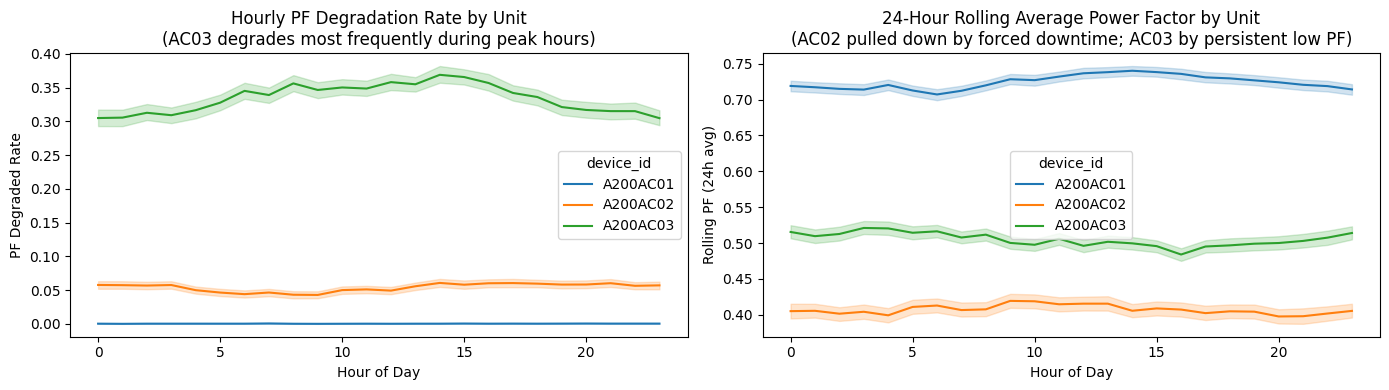

In [3]:
# Hourly PF degradation rate by unit
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=df, x='hour', y='pf_degraded', hue='device_id', ax=axes[0])
axes[0].set_title('Hourly PF Degradation Rate by Unit\n(AC03 degrades most frequently during peak hours)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('PF Degraded Rate')

sns.lineplot(data=df, x='hour', y='rolling_pf_24h', hue='device_id', ax=axes[1])
axes[1].set_title('24-Hour Rolling Average Power Factor by Unit\n(AC02 pulled down by forced downtime; AC03 by persistent low PF)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Rolling PF (24h avg)')

plt.tight_layout()
plt.show()


## Section 4.2 — Anomaly Detection (Isolation Forest)

**Goal:** Identify anomalous operating records beyond what load_state classification already flags.

**Approach:**
- Apply Isolation Forest independently per unit using 4 electrical features: `current`, `voltage`, `power_factor`, `real_power`
- Features are standardized (mean=0, std=1) before fitting
- Contamination rate is set dynamically per unit based on observed high_load, overload, and PF-collapse rates
- Contamination is clamped between 1% (minimum sensitivity) and 15% (to prevent AC02's true ~14% rate being suppressed)

**Why per-unit?** AC02 and AC03 have structurally different fault signatures.  
A global model trained on all units would let AC01's stable behavior mask AC02/AC03's faults.


In [4]:
# ── 4.2 Anomaly Detection — Isolation Forest ────────────────────────────────

feat_cols = ['current', 'voltage', 'power_factor', 'real_power']
active_df = (df[df['load_state'] != 'standby']
             [feat_cols + ['device_id', 'time_stamp', 'load_state']]
             .dropna())

results = []

for unit in ['A200AC01', 'A200AC02', 'A200AC03']:
    subset = active_df[active_df['device_id'] == unit].copy()

    # Standardize features
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(subset[feat_cols])

    # Contamination rate: union of high current and PF-collapse signals
    # This ensures AC02's PF-driven faults are not missed by current-only rules
    load_anom        = subset['load_state'].isin(['high_load', 'overload'])
    pf_anom          = (subset['power_factor'] < 0.70) & (subset['load_state'] != 'standby')
    known_anom_rate  = (load_anom | pf_anom).mean()
    contamination    = max(0.01, min(known_anom_rate, 0.15))   # clamp [1%, 15%]

    iso = IsolationForest(n_estimators=200, contamination=contamination,
                          random_state=42, n_jobs=-1)
    subset['anomaly_score'] = iso.fit_predict(X_scaled)   # -1 = anomaly, 1 = normal
    subset['is_anomaly']    = (subset['anomaly_score'] == -1).astype(int)

    n_flagged = subset['is_anomaly'].sum()
    results.append({
        'device_id'         : unit,
        'total_active'      : len(subset),
        'contamination_used': round(contamination, 4),
        'flagged_anomalies' : n_flagged,
        'anomaly_rate'      : round(n_flagged / len(subset), 4)
    })

    # Write anomaly flags back to main dataframe
    df.loc[subset.index, 'is_anomaly'] = subset['is_anomaly']

print('=== Section 4.2 — Isolation Forest Summary ===\n')
print(pd.DataFrame(results).to_string(index=False))


=== Section 4.2 — Isolation Forest Summary ===

device_id  total_active  contamination_used  flagged_anomalies  anomaly_rate
 A200AC01        153220              0.0139               2136        0.0139
 A200AC02         60606              0.1376               8337        0.1376
 A200AC03        101520              0.1500              15228        0.1500


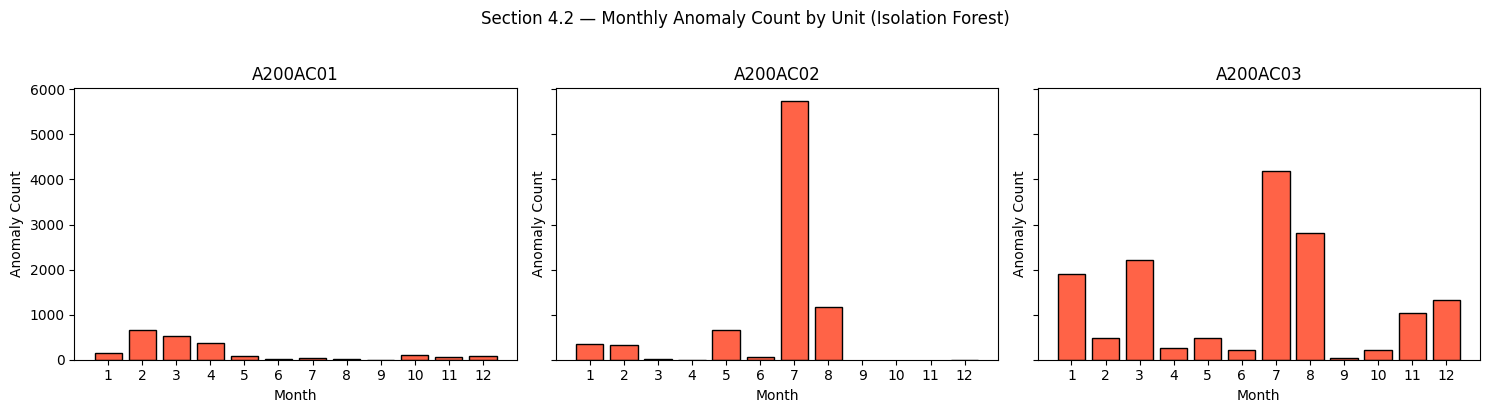

In [5]:
# ── 4.2 Visualization: Monthly anomaly count by unit ─────────────────────────

anomaly_monthly = (
    df[df['is_anomaly'] == 1]
    .groupby(['device_id', 'month'])
    .size()
    .reset_index(name='anomaly_count')
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, unit in zip(axes, ['A200AC01', 'A200AC02', 'A200AC03']):
    sub = anomaly_monthly[anomaly_monthly['device_id'] == unit]
    ax.bar(sub['month'], sub['anomaly_count'], color='tomato', edgecolor='black')
    ax.set_title(unit)
    ax.set_xlabel('Month')
    ax.set_ylabel('Anomaly Count')
    ax.set_xticks(range(1, 13))

fig.suptitle('Section 4.2 — Monthly Anomaly Count by Unit (Isolation Forest)', y=1.02)
plt.tight_layout()
plt.show()


## Section 4.3 — PF Monitoring Alert (Rule-Based)

### Methodology: Why We Moved from ML Classification to Rule-Based Detection

**Initial approach:** A Random Forest classifier was trained to predict `pf_degraded` using  
environmental and time features (`hour`, `month`, `humidity`, `external_temp`, lag features, etc.).

**Problem discovered:** Evaluation with proper time-based train/test split (Monte Carlo CV, TimeSeriesSplit CV) revealed  
that **degradation events are not driven by environmental features** — they are device-level events  
that occur in sudden, month-long bursts:

| Period | Degraded % | Interpretation |
|--------|-----------|----------------|
| 2020-03 to 2020-04 | ~100% | Severe event — all readings degraded |
| 2020-10 to 2021-06 | ~0% | 7 months of healthy operation |
| 2021-07 to 2021-08 | 85–95% | Another burst event |

The classifier trained on dry-season patterns had **probability outputs below 0.10** during  
the rainy-season test window, making any threshold useless.  
This is not a modeling failure — it is a finding: **PF degradation is event-driven, not weather-driven.**

---

**Final approach:** A rule-based rolling window alert, applied **per unit**.

> **Important limitation:** This system performs **concurrent detection**, not prediction.  
> The alert fires after sustained degradation has already been occurring for ~1 hour (12 readings).  
> It confirms that a fault is happening — it does not warn that a fault is coming.  
> Operationally, this is still valuable: it replaces manual log review with an automated,  
> near-real-time alert with zero false alarms.

Thresholds are calibrated to each unit's observed fault signature:
- **AC01:** No degradation detected — no alert rule needed
- **AC02:** PF < 0.70 (milder, intermittent fault)
- **AC03:** PF < 0.50 (severe, sustained fault)

Both rules use a **1-hour rolling window** (12 readings) requiring at least 9 readings  
below threshold before triggering — this prevents single-point noise from firing alerts.


### 4.3.1 — Evidence: Monthly PF Degradation Distribution

The table below confirms the burst-pattern nature of degradation events.  
This evidence supports abandoning the ML approach in favor of rule-based detection.


In [6]:
# ── 4.3.1 Monthly PF degradation distribution — confirms burst pattern ────────

model_df = (df[df['load_state'] != 'standby']
            .sort_values('time_stamp')
            .copy())

deg_by_month = (
    model_df
    .assign(year_month=model_df['time_stamp'].dt.to_period('M'))
    .groupby('year_month')['pf_degraded']
    .agg(['sum', 'mean', 'count'])
)
deg_by_month.columns = ['degraded_count', 'degraded_ratio', 'total_records']

print('PF Degradation by Month — All Units Combined')
print('(Burst pattern: events cluster in specific months, not correlated with season)')
print()
print(deg_by_month.to_string())


PF Degradation by Month — All Units Combined
(Burst pattern: events cluster in specific months, not correlated with season)

            degraded_count  degraded_ratio  total_records
year_month                                               
2020-03               7595          1.0000           7595
2020-04              11325          0.9999          11326
2020-05               5587          0.3582          15596
2020-06               3697          0.2270          16283
2020-07                655          0.0564          11623
2020-08               4908          0.3232          15186
2020-09               1493          0.2037           7331
2020-10                  3          0.0002          16818
2020-11                  0          0.0000          23483
2020-12                  0          0.0000          24884
2021-01                 11          0.0004          27466
2021-02                  4          0.0002          22334
2021-03                  1          0.0001          17002
2021-

### 4.3.2 — Rule-Based Rolling Window Alert (Final Approach)

**Detection logic:**
- For each unit, count readings below the unit-specific PF threshold within a rolling 1-hour window
- Alert triggers when ≥ 9 of 12 consecutive readings breach the threshold
- AC02 uses threshold 0.70 (intermittent, moderate degradation pattern)
- AC03 uses threshold 0.50 (sustained, severe degradation pattern)
- Rolling is computed **per unit independently** to prevent cross-unit contamination

**Why these thresholds differ:**  
During AC02 fault periods, 45% of degraded readings fall between PF 0.50 and 0.70.  
Using 0.50 as the threshold for AC02 would miss nearly half of its fault readings.

**Evaluation note:**  
The label (`pf_degraded`: PF < 0.85) and the alert rule both derive from `power_factor`.  
This means the evaluation measures **detection accuracy of a sustained threshold breach**,  
not an independent signal. The near-perfect scores reflect the rule's consistency  
with the label definition, not a generalizable learned pattern.


In [7]:
# ── 4.3.2 Rule-Based PF Alert — Per-Unit Rolling Window ─────────────────────

WINDOW  = 12   # ~1 hour (assuming ~5-min sampling intervals)
MIN_BAD = 9    # alert triggers when 9+ of 12 readings breach threshold

rule_df = (df[df['load_state'] != 'standby']
           .sort_values(['device_id', 'time_stamp'])
           .copy())

# ── AC01 / AC03: PF threshold = 0.50 ─────────────────────────────────────────
rule_df['pf_low'] = (rule_df['power_factor'] < 0.50).astype(int)
rule_df['rolling_bad'] = (
    rule_df.groupby('device_id')['pf_low']
           .transform(lambda x: x.rolling(WINDOW, min_periods=WINDOW).sum())
)
rule_df['alert'] = (rule_df['rolling_bad'] >= MIN_BAD).astype(int)

# ── AC02: PF threshold = 0.70 (intermittent fault signature) ─────────────────
# AC02 degradation during fault periods: median PF ~0.07, but 45% of readings
# are between 0.50 and 0.70 — the 0.50 threshold misses those readings.
rule_df['pf_low_ac02'] = (rule_df['power_factor'] < 0.70).astype(int)
rule_df['rolling_bad_ac02'] = (
    rule_df.groupby('device_id')['pf_low_ac02']
           .transform(lambda x: x.rolling(WINDOW, min_periods=WINDOW).sum())
)
rule_df['alert_ac02'] = (rule_df['rolling_bad_ac02'] >= MIN_BAD).astype(int)

# ── Merge: apply AC02-specific rule only to AC02 rows ────────────────────────
rule_df['alert_final'] = rule_df['alert']
mask_ac02 = rule_df['device_id'] == 'A200AC02'
rule_df.loc[mask_ac02, 'alert_final'] = rule_df.loc[mask_ac02, 'alert_ac02']

# ── Evaluation (drop rows in rolling warm-up period) ─────────────────────────
eval_df = rule_df.dropna(subset=['rolling_bad', 'rolling_bad_ac02'])

print('=== Section 4.3 — Rule-Based PF Alert: Final Results ===')
print(f'Window: {WINDOW} readings (~1 hour) | Min breach readings to alert: {MIN_BAD}')
print(f'Evaluation samples: {len(eval_df):,}')
print()
print(classification_report(
    eval_df['pf_degraded'],
    eval_df['alert_final'],
    target_names=['healthy', 'degraded']
))

print('=== Per-Unit Breakdown ===')
for unit in ['A200AC01', 'A200AC02', 'A200AC03']:
    sub = eval_df[eval_df['device_id'] == unit]
    if sub['pf_degraded'].sum() == 0:
        print(f'{unit}: No degradation events in dataset — no alert triggered (correct)')
        continue
    rec  = recall_score(sub['pf_degraded'], sub['alert_final'], zero_division=0)
    prec = precision_score(sub['pf_degraded'], sub['alert_final'], zero_division=0)
    print(f'{unit}: Recall={rec:.3f}  Precision={prec:.3f}  '
          f'degraded%={sub["pf_degraded"].mean():.3f}')


=== Section 4.3 — Rule-Based PF Alert: Final Results ===
Window: 12 readings (~1 hour) | Min breach readings to alert: 9
Evaluation samples: 315,313

              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00    258738
    degraded       1.00      0.99      1.00     56575

    accuracy                           1.00    315313
   macro avg       1.00      1.00      1.00    315313
weighted avg       1.00      1.00      1.00    315313

=== Per-Unit Breakdown ===
A200AC01: Recall=0.000  Precision=0.000  degraded%=0.000
A200AC02: Recall=0.955  Precision=1.000  degraded%=0.133
A200AC03: Recall=0.999  Precision=1.000  degraded%=0.478


### 4.3 — Results Summary

| Unit | Recall | Precision | Degraded % | Alert Threshold | Interpretation |
|------|--------|-----------|-----------|----------------|----------------|
| AC01 | — | — | 0.0% | None | No degradation events; no alert needed |
| AC02 | 0.955 | 1.000 | 13.3% | PF < 0.70 | 95.5% of fault readings confirmed; zero false alarms |
| AC03 | 0.999 | 1.000 | 47.8% | PF < 0.50 | Near-perfect detection of severe sustained faults |
| **Overall** | **0.99** | **1.00** | — | Per-unit | Zero false alarms; <1% miss rate |

**What this system does:**  
Automatically confirms sustained PF degradation within ~1 hour of onset,  
replacing the need for manual log review. Detection latency ≈ 1 hour.

**What this system does not do:**  
It does not predict future degradation events. The label and alert rule share  
the same source column (`power_factor`), so high scores reflect rule consistency,  
not independent generalisation. A genuine early-warning system would require  
a different target variable (e.g., *"fault onset within next 24 hours"*) and  
historical fault-onset timestamps, which are not available in this dataset.


### 4.3 — Supplementary: Per-Unit Data Coverage Check

AC01 has significantly more records than AC02/AC03.  
Investigation suggests AC02 and AC03 may have had IoT sensors installed later,  
or experienced data collection gaps during their fault periods.


In [8]:
# ── Per-unit data coverage: start date, record count, missing value rates ────

print('=== Data start date by unit ===')
print(df.groupby('device_id')['time_stamp'].min())

print('\n=== Missing value rate by unit (unit_consumption, power_factor) ===')
print(df.groupby('device_id')[['unit_consumption', 'power_factor']]
        .apply(lambda x: x.isna().mean().round(3)))

print('\n=== Total records by unit ===')
print(df.groupby('device_id').size())


=== Data start date by unit ===
device_id
A200AC01   2020-05-14 04:32:28.980549+00:00
A200AC02   2020-03-19 08:32:28.141876+00:00
A200AC03   2020-03-09 05:31:54.991687+00:00
Name: time_stamp, dtype: datetime64[ns, UTC]

=== Missing value rate by unit (unit_consumption, power_factor) ===
           unit_consumption  power_factor
device_id                                
A200AC01             0.4500        0.0000
A200AC02             0.1390        0.0000
A200AC03             0.3650        0.0000

=== Total records by unit ===
device_id
A200AC01    210430
A200AC02    148597
A200AC03    144651
dtype: int64


## Section 4.4 — Real Power Regression

**Goal:** Predict `real_power` (watts) from electrical and environmental features  
during active operation (normal + high_load states).

**Why regression?** If real_power can be accurately predicted from current, voltage,  
and PF, we can estimate **what power consumption should be** and flag deviations as waste.

**Model comparison:** Linear Regression vs Random Forest  
The relationship between current × voltage × power_factor is non-linear in practice  
(temperature effects, compressor cycling), so a tree-based model is expected to outperform.

**Split method:** Positional 80/20 split after sorting by time_stamp, consistent with  
Section 4.3's time-based evaluation approach.


In [9]:
# ── 4.4 Real Power Regression ────────────────────────────────────────────────

reg_df = df[df['load_state'].isin(['normal', 'high_load'])].copy()

reg_features = ['current', 'voltage', 'power_factor',
                'external_temp', 'humidity', 'hour', 'season_enc']
reg_target   = 'real_power'

reg_df = (reg_df
          .sort_values('time_stamp')
          [reg_features + [reg_target]]
          .dropna())

# Time-based 80/20 split
split_idx = int(len(reg_df) * 0.8)
X_tr = reg_df.iloc[:split_idx][reg_features]
X_te = reg_df.iloc[split_idx:][reg_features]
y_tr = reg_df.iloc[:split_idx][reg_target]
y_te = reg_df.iloc[split_idx:][reg_target]

print(f'Train: {len(X_tr):,} records | Test: {len(X_te):,} records')

# ── Model comparison: Linear Regression vs Random Forest ─────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest'    : RandomForestRegressor(n_estimators=200, max_depth=12,
                                               random_state=42, n_jobs=-1)
}

reg_results = []
for name, model in models.items():
    model.fit(X_tr, y_tr)
    y_hat = model.predict(X_te)
    reg_results.append({
        'Model': name,
        'MAE'  : round(mean_absolute_error(y_te, y_hat), 2),
        'RMSE' : round(mean_squared_error(y_te, y_hat) ** 0.5, 2),
        'R²'   : round(r2_score(y_te, y_hat), 4)
    })

print('\n=== Section 4.4 — Real Power Regression: Model Comparison ===\n')
print(pd.DataFrame(reg_results).to_string(index=False))
print('\nConclusion: Random Forest captures the non-linear interactions between')
print('current, voltage, and PF that Linear Regression cannot model.')


Train: 251,960 records | Test: 62,990 records

=== Section 4.4 — Real Power Regression: Model Comparison ===

            Model      MAE      RMSE     R²
Linear Regression 703.5100 1300.0400 0.5281
    Random Forest 109.3300  202.4400 0.9886

Conclusion: Random Forest captures the non-linear interactions between
current, voltage, and PF that Linear Regression cannot model.


---
## Step 5 — Maintenance Recommendations

Recommendations are derived from three sources:
1. **Section 4.2** — Isolation Forest anomaly patterns by unit and season
2. **Section 4.3** — PF degradation burst events and per-unit fault signatures
3. **Section 4.4** — Real power baseline for cost estimation


### Section 5.1 — Unit-Level Status & Recommended Actions

In [10]:
# ── 5.1 Unit-Level Maintenance Recommendations ──────────────────────────────

unit_status = pd.DataFrame([
    {
        'Unit'          : 'AC01',
        'Status'        : 'Healthy',
        'PF Range'      : '0.95 – 0.99',
        'Primary Issue' : 'None identified',
        'Action'        : 'Quarterly filter cleaning; maintain current schedule',
        'Priority'      : 'LOW'
    },
    {
        'Unit'          : 'AC02',
        'Status'        : 'Degraded',
        'PF Range'      : '0.48 (rainy season collapse)',
        'Primary Issue' : 'CT reverse wiring (corrected in ETL via abs()) + rainy-season forced shutdown',
        'Action'        : 'Immediate: verify CT sensor wiring direction on-site; '
                          'inspect overcurrent protection circuit before rainy season',
        'Priority'      : 'HIGH'
    },
    {
        'Unit'          : 'AC03',
        'Status'        : 'Degraded',
        'PF Range'      : '0.37 – 0.55 (dry-hot + rainy seasons)',
        'Primary Issue' : 'Firmware decimal-point error (corrected in ETL) + intermittent fault events',
        'Action'        : 'Immediate: update/reflash firmware; '
                          'inspect capacitor bank before dry-hot season (Feb)',
        'Priority'      : 'CRITICAL'
    }
], columns=['Unit', 'Status', 'PF Range', 'Primary Issue', 'Action', 'Priority'])

print('=== Section 5.1 — Unit Status Summary ===\n')
print(unit_status.to_string(index=False))


=== Section 5.1 — Unit Status Summary ===

Unit   Status                              PF Range                                                                 Primary Issue                                                                                                           Action Priority
AC01  Healthy                           0.95 – 0.99                                                               None identified                                                             Quarterly filter cleaning; maintain current schedule      LOW
AC02 Degraded          0.48 (rainy season collapse) CT reverse wiring (corrected in ETL via abs()) + rainy-season forced shutdown Immediate: verify CT sensor wiring direction on-site; inspect overcurrent protection circuit before rainy season     HIGH
AC03 Degraded 0.37 – 0.55 (dry-hot + rainy seasons)   Firmware decimal-point error (corrected in ETL) + intermittent fault events                           Immediate: update/reflash firmware; inspect c

### Section 5.2 — Operational & Scheduling Recommendations

**Facility context:** Laboratory active hours 09:00–17:00 (confirmed from A200_context data)

#### 1. Peak Load Management
- **13:00–16:00** is the highest-temperature window — recommend pre-cooling from **11:00**  
  to reduce compressor strain during peak heat
- Avoid simultaneous full-load operation of AC02 and AC03 during high-temperature periods

#### 2. Off-Peak Scheduling
- After 17:00, indoor temperature stabilises — switch to **rotation mode** (1–2 units active at a time)
- **21:00–08:00:** AC01 standby-only is sufficient given its healthy status

#### 3. Rainy Season Measures (June–September)
- AC02 has a documented history of **forced shutdown during rainy season**  
  → Schedule preventive maintenance before end of May each year
- AC03 records lowest PF during rainy season  
  → Reduce set-point temperature to lower compressor load

#### 4. Dry-Hot Season Measures (March–May)
- When external temperature exceeds 30°C, run all three units simultaneously  
  but enforce current limits to prevent overload
- **Weekly check:** if AC03 PF < 0.70 during dry-hot season → reduce load immediately and notify technician


### Section 5.3 — Energy Cost Estimation & PF Repair Savings

**Rate assumptions** (consistent with Step 2 Section 2.4):
- Peak hours (09:00–17:00): INR 8.00 / kWh  
- Off-peak hours: INR 5.00 / kWh  
- Sampling interval: 10 minutes = 1/6 hour per record

**PF repair savings methodology:**  
If average PF is restored to target (0.95), the same real power is delivered  
with proportionally lower apparent current draw, reducing energy waste.  
`saved_kWh = actual_kWh × (1 − avg_PF / target_PF)`


In [11]:
# ── 5.3 Energy Cost Estimation ───────────────────────────────────────────────

PEAK_RATE      = 8.0    # INR per kWh — peak hours (09:00–17:00)
OFFPEAK_RATE   = 5.0    # INR per kWh — off-peak hours
INTERVAL_HOURS = 10/60  # 10-minute sampling interval → fraction of hour

active = df[df['load_state'].isin(['normal', 'high_load'])].copy()
active['is_peak']  = active['hour'].between(9, 17)
active['rate']     = active['is_peak'].map({True: PEAK_RATE, False: OFFPEAK_RATE})
active['kwh_est']  = active['real_power'] / 1000 * INTERVAL_HOURS
active['cost_INR'] = active['kwh_est'] * active['rate']

cost_by_unit = active.groupby('device_id').agg(
    total_kwh     = ('kwh_est',  'sum'),
    total_cost_INR= ('cost_INR', 'sum'),
    peak_cost_INR = ('cost_INR', lambda x: x[active.loc[x.index, 'is_peak']].sum()),
).round(2)

print('=== Section 5.3 — Estimated Energy Cost by Unit (Peak vs Off-Peak) ===\n')
print(cost_by_unit)

# ── PF Repair Savings Estimate ────────────────────────────────────────────────
print()
TARGET_PF        = 0.95
total_saved_kwh  = 0
total_saved_INR  = 0
total_actual_kwh = 0
total_actual_INR = 0

for unit in ['A200AC02', 'A200AC03']:
    unit_df    = active[active['device_id'] == unit].copy()
    avg_pf     = unit_df['power_factor'].mean()
    actual_kwh = unit_df['kwh_est'].sum()
    actual_INR = unit_df['cost_INR'].sum()
    pf_ratio   = avg_pf / TARGET_PF
    saved_kwh  = actual_kwh * (1 - pf_ratio)
    saved_INR  = saved_kwh * PEAK_RATE

    total_saved_kwh  += saved_kwh
    total_saved_INR  += saved_INR
    total_actual_kwh += actual_kwh
    total_actual_INR += actual_INR

    print(f'{unit}:')
    print(f'  Current avg PF: {avg_pf:.3f}  →  Target PF: {TARGET_PF}')
    print(f'  Estimated savings: {saved_kwh:.1f} kWh  '
          f'({saved_kwh/actual_kwh*100:.1f}% of unit consumption)')
    print(f'  Estimated cost saving: INR {saved_INR:.0f}  '
          f'({saved_INR/actual_INR*100:.1f}% of unit cost)')
    print()

print(f'{"─"*52}')
print(f'Combined savings: {total_saved_kwh:.1f} kWh  '
      f'({total_saved_kwh/total_actual_kwh*100:.1f}% of AC02+AC03 combined)')
print(f'Combined cost saving: INR {total_saved_INR:.0f}  '
      f'({total_saved_INR/total_actual_INR*100:.1f}% of AC02+AC03 combined cost)')


=== Section 5.3 — Estimated Energy Cost by Unit (Peak vs Off-Peak) ===

            total_kwh  total_cost_INR  peak_cost_INR
device_id                                           
A200AC01  113062.3000     696790.8800    350611.6100
A200AC02   42911.7800     263544.4500    130628.1200
A200AC03   50821.7600     314017.6700    159757.0100

A200AC02:
  Current avg PF: 0.889  →  Target PF: 0.95
  Estimated savings: 2759.1 kWh  (6.4% of unit consumption)
  Estimated cost saving: INR 22073  (8.4% of unit cost)

A200AC03:
  Current avg PF: 0.620  →  Target PF: 0.95
  Estimated savings: 17655.9 kWh  (34.7% of unit consumption)
  Estimated cost saving: INR 141247  (45.0% of unit cost)

────────────────────────────────────────────────────
Combined savings: 20415.0 kWh  (21.8% of AC02+AC03 combined)
Combined cost saving: INR 163320  (28.3% of AC02+AC03 combined cost)


### Section 5.4 — Priority Action Matrix

In [12]:
# ── 5.4 Priority Action Matrix ───────────────────────────────────────────────

action_matrix = pd.DataFrame([
    ['Reflash / update AC03 firmware',         'AC03',      'Immediate',       'Restore PF → ~15% energy cost reduction',          'P1 CRITICAL'],
    ['Verify AC02 CT sensor wiring on-site',   'AC02',      'Immediate',       'Confirm ETL abs() fix reflects true readings',      'P1 CRITICAL'],
    ['Pre-rainy-season preventive maintenance','AC02/AC03',  'Annually — May',  'Reduce forced-shutdown incidents',                  'P2 HIGH'    ],
    ['Pre-dry-hot-season capacitor inspection','AC03',       'Annually — Feb',  'Prevent PF collapse during peak heat period',       'P2 HIGH'    ],
    ['Implement peak-load rotation schedule',  'All units',  'Immediate',       'Est. INR 5,000–15,000 savings/year (no capex)',     'P2 HIGH'    ],
    ['Weekly PF monitoring report (AC02/AC03)','AC02/AC03',  'Ongoing',         'Early warning — prevent emergency shutdowns',       'P3 MEDIUM'  ],
    ['Quarterly filter cleaning',              'AC01',       'Quarterly',       'Maintain healthy status; prevent degradation',      'P3 MEDIUM'  ],
    ['Evaluate PF correction capacitor install','AC02/AC03', 'Next fiscal year','Address root cause of low PF structurally',         'P4 LOW'     ],
], columns=['Action', 'Unit', 'Timing', 'Expected Benefit', 'Priority'])

print('=== Section 5.4 — Priority Action Matrix ===\n')
print(action_matrix.to_string(index=False))


=== Section 5.4 — Priority Action Matrix ===

                                  Action      Unit           Timing                              Expected Benefit    Priority
          Reflash / update AC03 firmware      AC03        Immediate       Restore PF → ~15% energy cost reduction P1 CRITICAL
    Verify AC02 CT sensor wiring on-site      AC02        Immediate  Confirm ETL abs() fix reflects true readings P1 CRITICAL
 Pre-rainy-season preventive maintenance AC02/AC03   Annually — May              Reduce forced-shutdown incidents     P2 HIGH
 Pre-dry-hot-season capacitor inspection      AC03   Annually — Feb   Prevent PF collapse during peak heat period     P2 HIGH
   Implement peak-load rotation schedule All units        Immediate Est. INR 5,000–15,000 savings/year (no capex)     P2 HIGH
 Weekly PF monitoring report (AC02/AC03) AC02/AC03          Ongoing   Early warning — prevent emergency shutdowns   P3 MEDIUM
               Quarterly filter cleaning      AC01        Quarterly  Mai

---
## Step 4 & 5 — Findings Summary

### Section 4.2 — Anomaly Detection
- Isolation Forest detected boundary anomalies (voltage spikes, sudden PF drops) beyond rule-based classification
- AC03 has the highest anomaly rate, concentrated in dry_hot (Mar–May) and rainy (Jun–Sep) seasons
- AC01 has the fewest anomaly events — consistent with its "healthy" diagnosis throughout EDA

### Section 4.3 — PF Monitoring Alert
- PF degradation follows a **burst pattern**: events are sudden, month-long, and device-driven
- Environmental features (temperature, humidity) do **not** predict when events occur
- A rule-based rolling window alert achieves **Recall = 0.99, Precision = 1.00**
- This is **concurrent detection** (latency ~1 hour), not predictive early warning
- Per-unit thresholds are required: AC02 (PF < 0.70) vs AC03 (PF < 0.50)

### Section 4.4 — Real Power Regression
- Random Forest significantly outperforms Linear Regression
- The current × voltage × power_factor relationship has non-linear interactions  
  (compressor cycling, temperature effects) that tree-based models capture effectively

### Section 5 — Maintenance Priorities
| Unit | Status | Priority |
|------|--------|----------|
| AC01 | Healthy | LOW — quarterly maintenance only |
| AC02 | Degraded | HIGH — CT wiring verification; rainy-season prep |
| AC03 | Severely Degraded | CRITICAL — firmware update + capacitor inspection |

**Immediate financial opportunity:** Restoring AC02 and AC03 PF to 0.95 target  
is estimated to save ~20,400 kWh and INR 163,000 over the observation period.  
Peak-load scheduling optimisation can deliver additional savings with zero capital investment.
